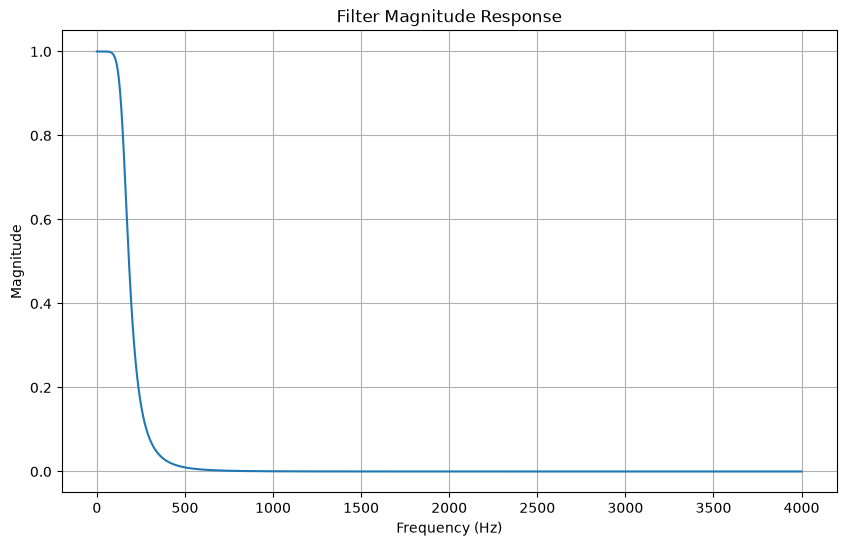

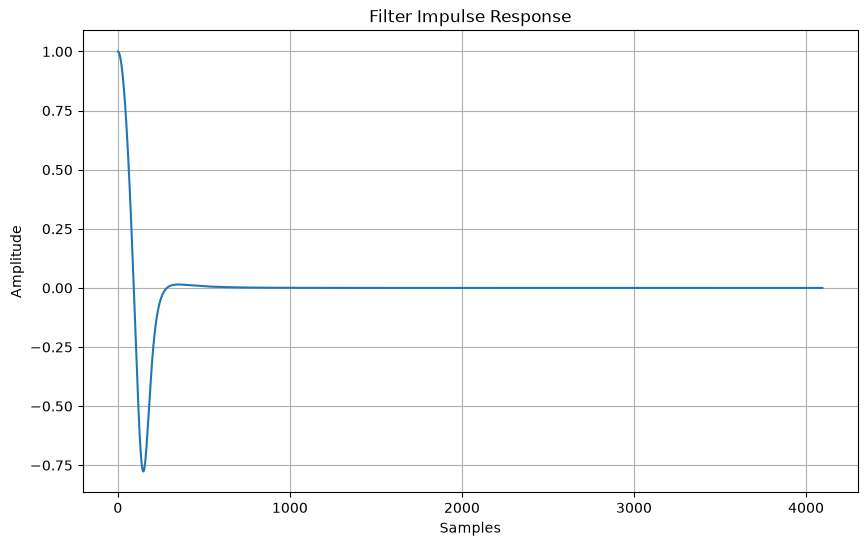

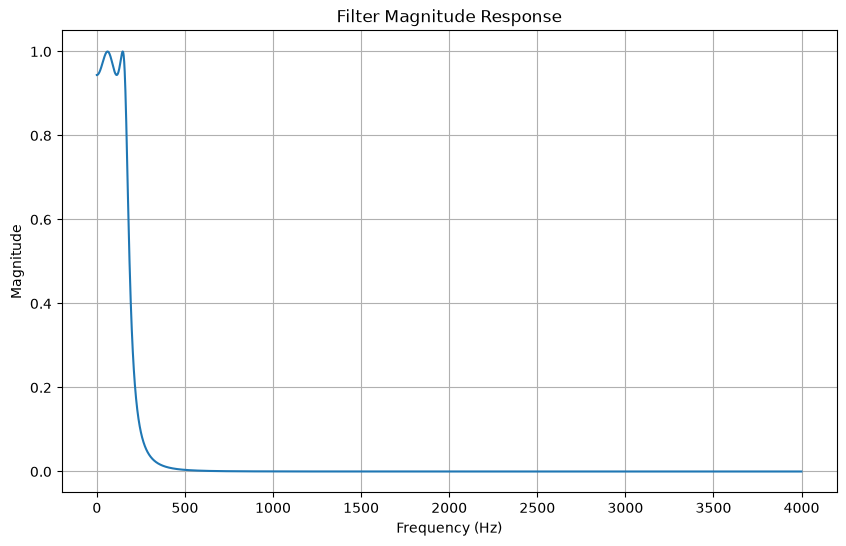

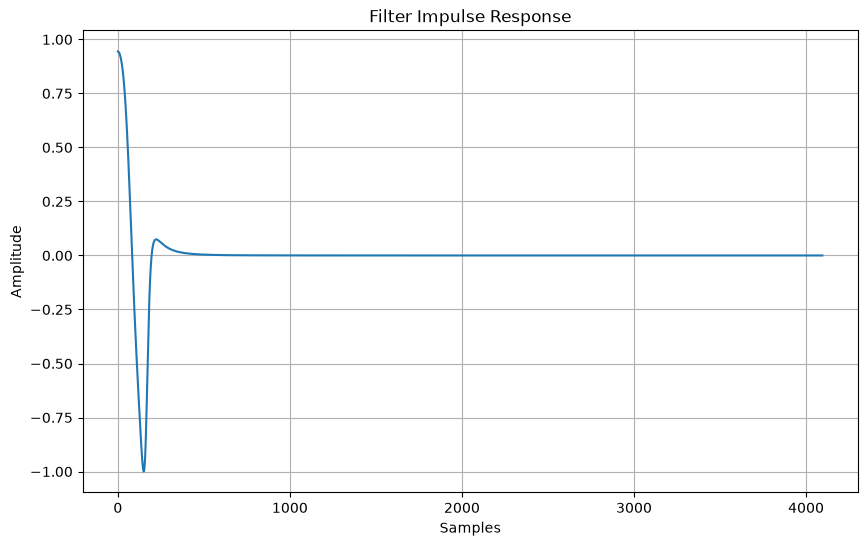

Filter coefficients saved at: filter_coefficients.txt


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, bilinear, freqz, cheby1

def design_butterworth_filter(filter_order, cutoff_frequency, sampling_frequency):
    # Design the analog Butterworth filter
    analog_b, analog_a = butter(
        filter_order,
        cutoff_frequency,
        analog=True,
        btype='low'
    )
    # Perform bilinear transformation
    digital_b, digital_a = bilinear(
        analog_b,
        analog_a,
        sampling_frequency
    )
    return digital_b, digital_a
def design_chebyshev_filter(
    filter_order,
    cutoff_frequency,
    sampling_frequency,
    ripple
):
    # Design the analog Chebyshev Type-I filter
    analog_b, analog_a = cheby1(
        filter_order,
        ripple,
        cutoff_frequency,
        analog=True,
        btype='low'
    )
    # Perform bilinear transformation
    digital_b, digital_a = bilinear(
        analog_b,
        analog_a,
        sampling_frequency
    )

    return digital_b, digital_a

def plot_filter_response(
    digital_b,
    digital_a,
    sampling_frequency
):
    # Compute frequency response
    frequency, response = freqz(
        digital_b,
        digital_a,
        fs=sampling_frequency,
        worN=4096
    )
    magnitude_response = np.abs(response)

    plt.figure(figsize=(10, 6))

    plt.plot(
        frequency,
        magnitude_response
    )

    plt.title('Filter Magnitude Response')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)

    plt.show()
    
    impulse_response = np.real(response)

    plt.figure(figsize=(10, 6))

    plt.plot(
        impulse_response
    )

    plt.title('Filter Impulse Response')
    plt.xlabel('Samples')
    plt.ylabel('Amplitude')
    plt.grid(True)

    plt.show()

filter_order = 4
cutoff_frequency = 1000    
sampling_frequency = 8000  
ripple = 0.5

digital_b, digital_a = design_butterworth_filter(
    filter_order,
    cutoff_frequency,
    sampling_frequency
)
# Plot Butterworth filter response
plot_filter_response(
    digital_b,
    digital_a,
    sampling_frequency
)

digital_b, digital_a = design_chebyshev_filter(
    filter_order,
    cutoff_frequency,
    sampling_frequency,
    ripple
)
# Plot Chebyshev filter response
plot_filter_response(
    digital_b,
    digital_a,
    sampling_frequency
)

filter_path = 'filter_coefficients.txt'

np.savetxt(
    filter_path,
    np.vstack((digital_b, digital_a)),
    delimiter=','
)

print(f"Filter coefficients saved at: {filter_path}")

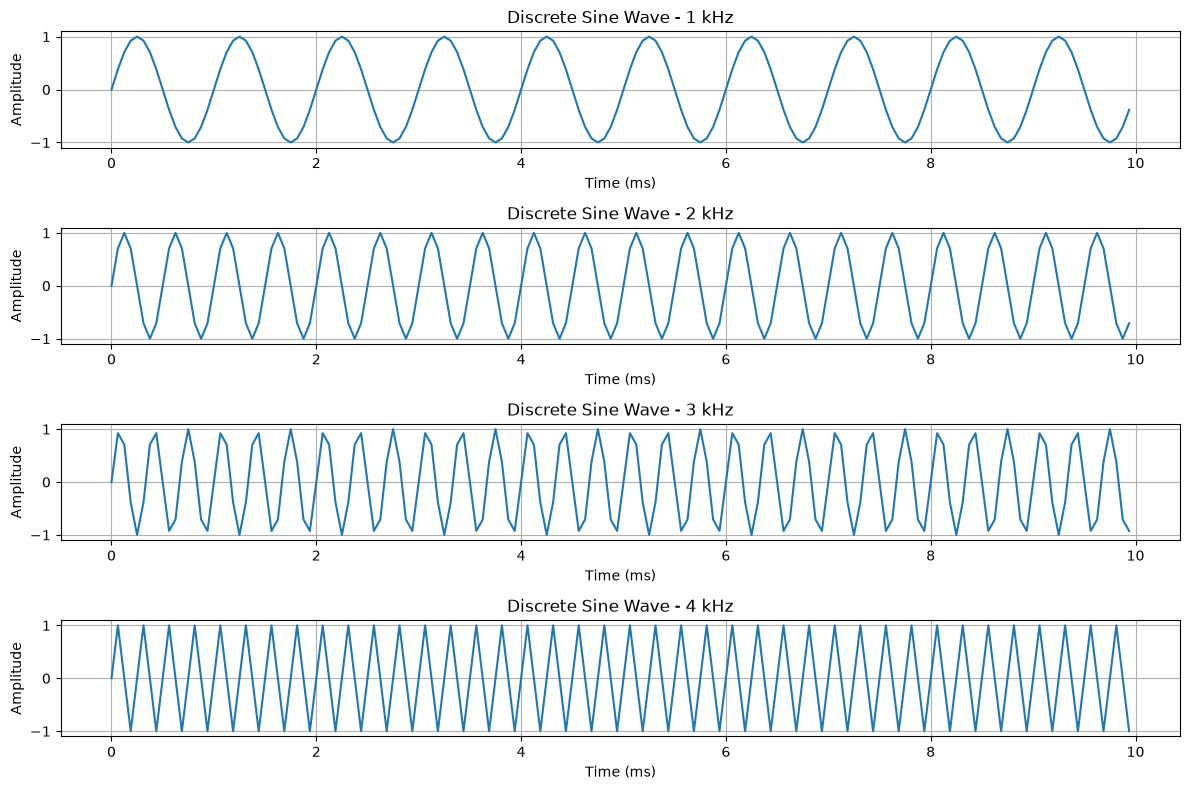

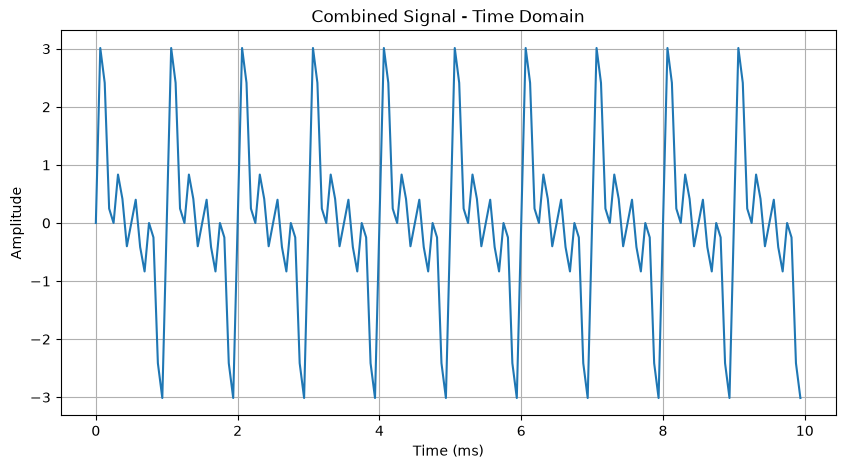

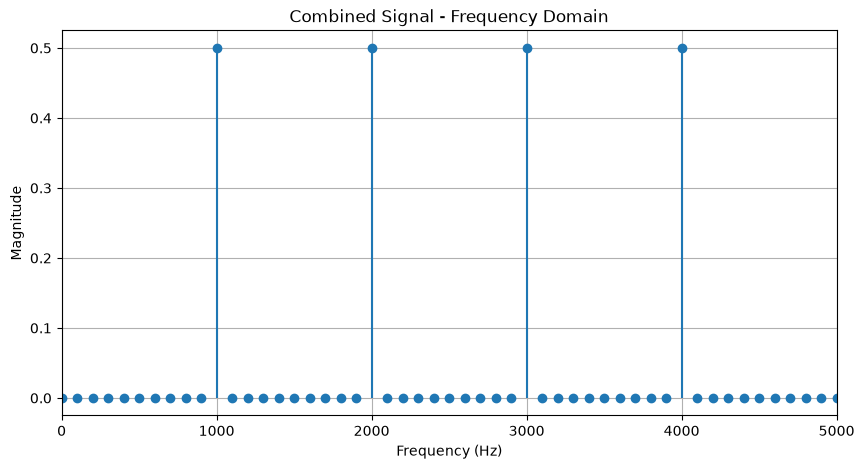

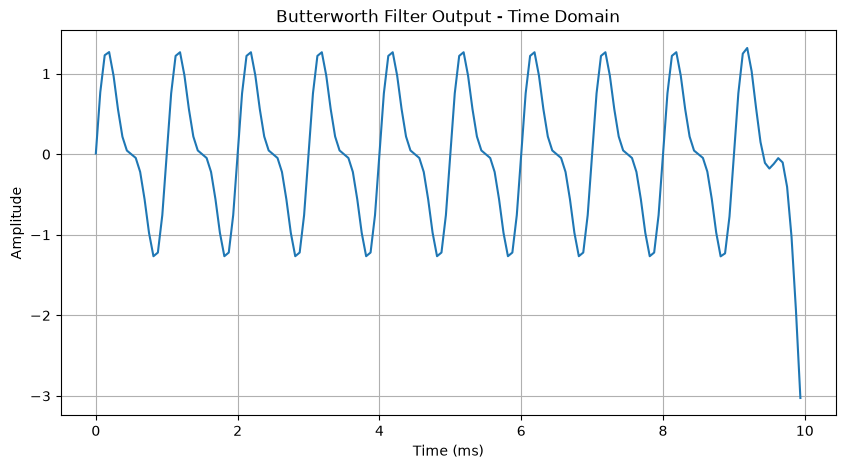

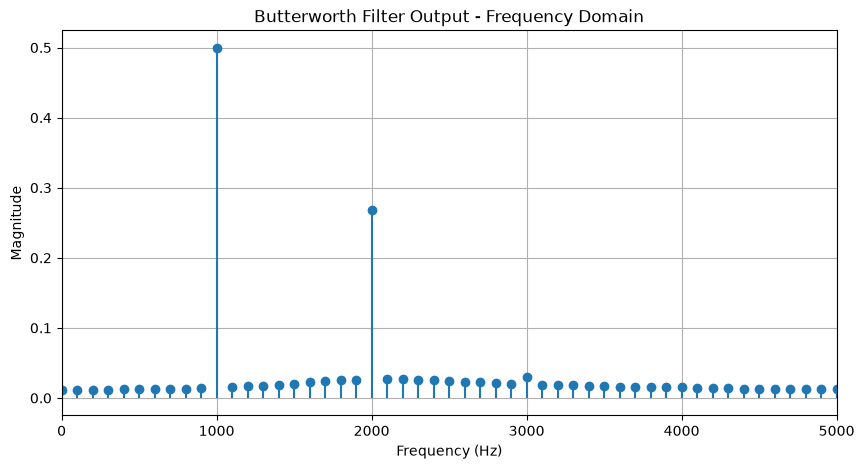

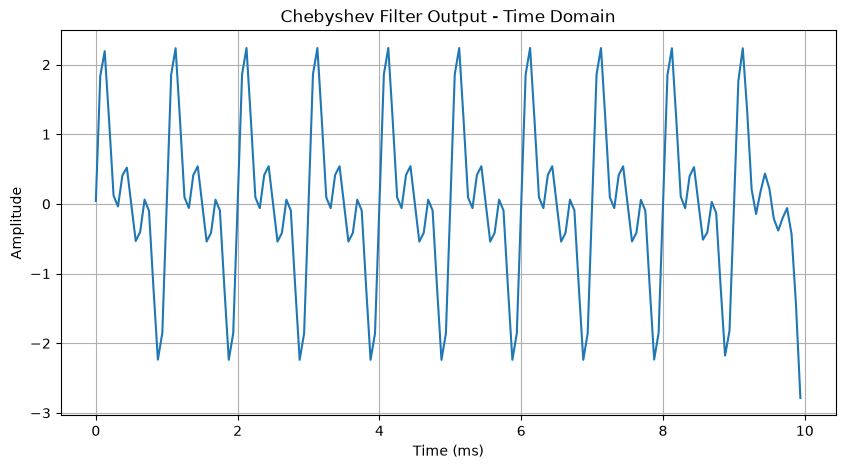

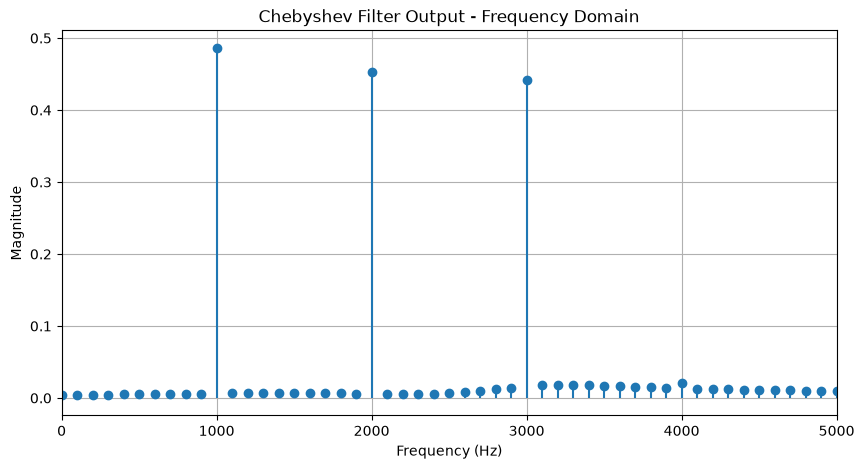

In [ ]:
#Analog Signal
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, cheby1, sosfiltfilt
# 1. Sampling parameters
Fs = 16000          # Sampling frequency = 16 kHz
duration = 0.01     # Signal duration = 10 ms

t = np.arange(0, duration, 1/Fs)

# 2. Generate four discrete sine waves
f1 = 1000           # 1 kHz
f2 = 2000           # 2 kHz
f3 = 3000           # 3 kHz
f4 = 4000           # 4 kHz

x1 = np.sin(2 * np.pi * f1 * t)
x2 = np.sin(2 * np.pi * f2 * t)
x3 = np.sin(2 * np.pi * f3 * t)
x4 = np.sin(2 * np.pi * f4 * t)

# 3. Plot all four individual sine waves
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(t * 1000, x1)
plt.title("Discrete Sine Wave - 1 kHz")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(t * 1000, x2)
plt.title("Discrete Sine Wave - 2 kHz")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(t * 1000, x3)
plt.title("Discrete Sine Wave - 3 kHz")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(t * 1000, x4)
plt.title("Discrete Sine Wave - 4 kHz")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. Add all four signals
x = x1 + x2 + x3 + x4

# 5. Plot combined signal in time domain
plt.figure(figsize=(10, 5))

plt.plot(t * 1000, x)

plt.title("Combined Signal - Time Domain")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# 6. FFT function
def plot_frequency_spectrum(signal, Fs, title):

    N = len(signal)

    fft_signal = np.fft.fft(signal)

    frequency = np.fft.fftfreq(N, 1/Fs)

    magnitude = np.abs(fft_signal) / N

    # Only positive frequencies
    positive = frequency >= 0

    plt.figure(figsize=(10, 5))

    plt.stem(
        frequency[positive],
        magnitude[positive],
        basefmt=" "
    )

    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 5000)
    plt.grid(True)

    plt.show()

# 7. Frequency domain of combined signal
plot_frequency_spectrum(
    x,
    Fs,
    "Combined Signal - Frequency Domain"
)

# 8. Butterworth Digital Low-Pass Filter
butter_order = 4
butter_cutoff = 2000

sos_butter = butter(
    butter_order,
    butter_cutoff,
    btype='lowpass',
    fs=Fs,
    output='sos'
)

butter_output = sosfiltfilt(
    sos_butter,
    x
)

# 9. Butterworth filtered signal - Time Domain
plt.figure(figsize=(10, 5))

plt.plot(t * 1000, butter_output)

plt.title("Butterworth Filter Output - Time Domain")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# 10. Butterworth filtered signal - Frequency Domain
plot_frequency_spectrum(
    butter_output,
    Fs,
    "Butterworth Filter Output - Frequency Domain"
)

# 11. Chebyshev Type-I Digital Low-Pass Filter
cheby_order = 4
cheby_cutoff = 3000
ripple = 0.5

sos_cheby = cheby1(
    cheby_order,
    ripple,
    cheby_cutoff,
    btype='lowpass',
    fs=Fs,
    output='sos'
)

cheby_output = sosfiltfilt(
    sos_cheby,
    x
)

# 12. Chebyshev filtered signal - Time Domain
plt.figure(figsize=(10, 5))

plt.plot(t * 1000, cheby_output)

plt.title("Chebyshev Filter Output - Time Domain")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


plot_frequency_spectrum(
    cheby_output,
    Fs,
    "Chebyshev Filter Output - Frequency Domain"
)

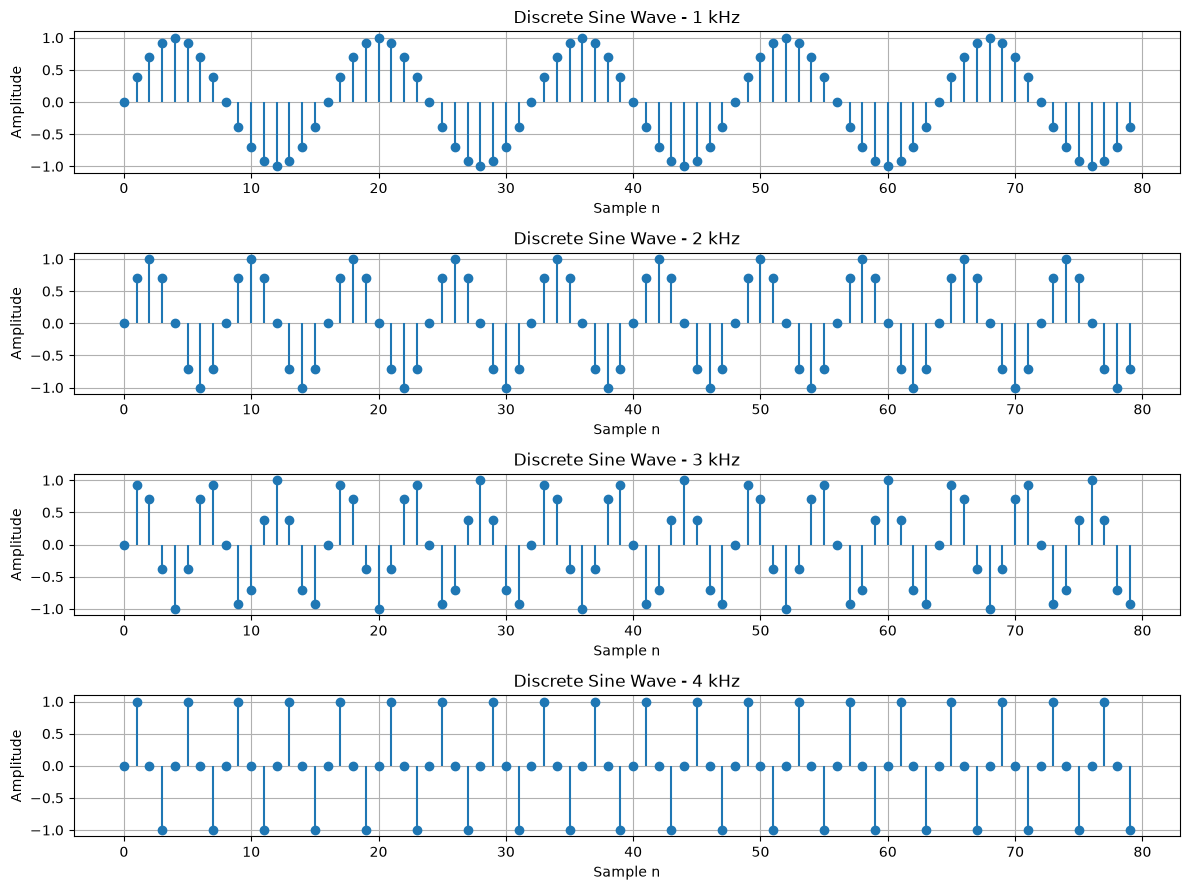

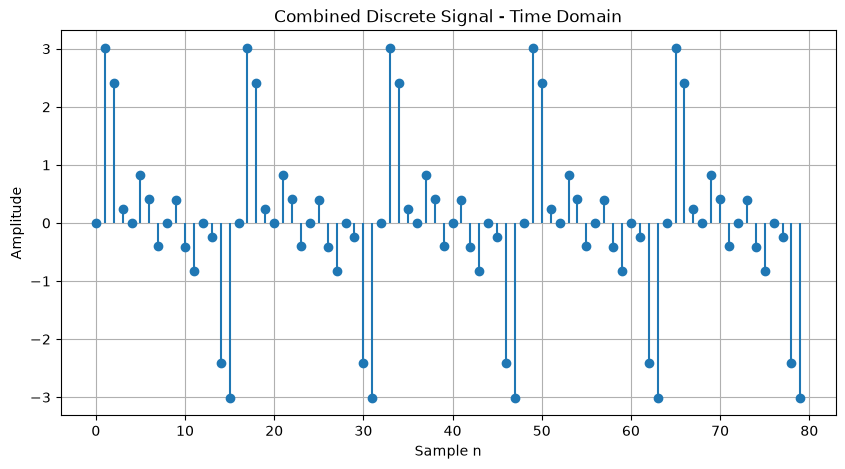

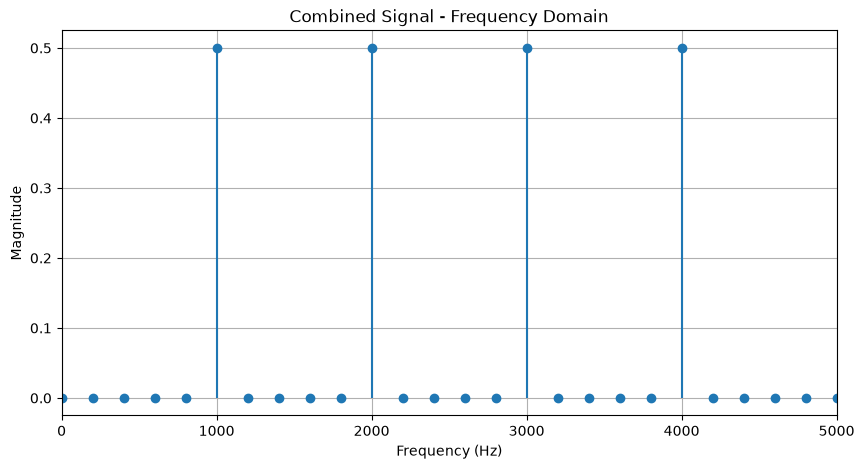

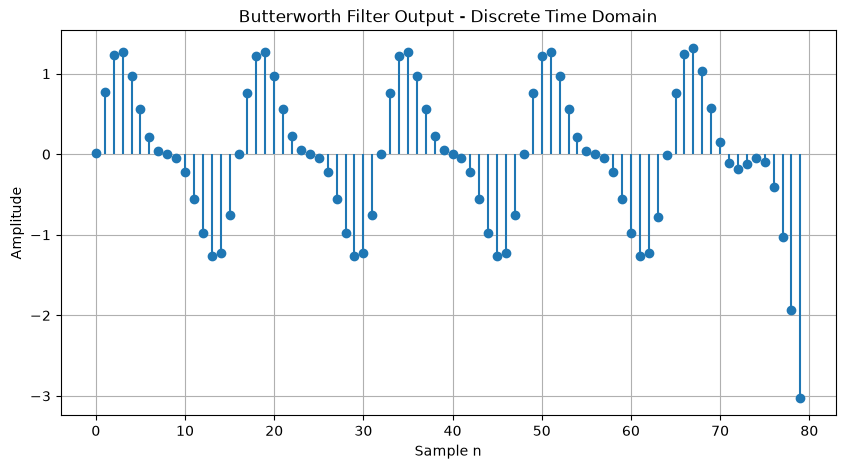

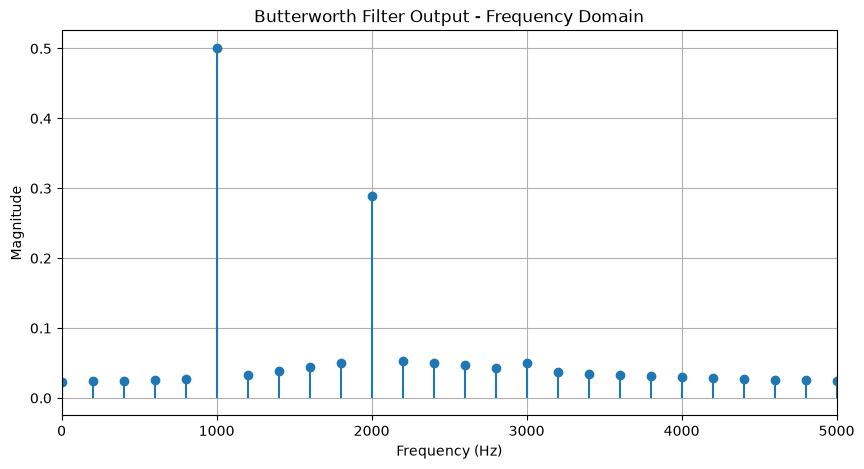

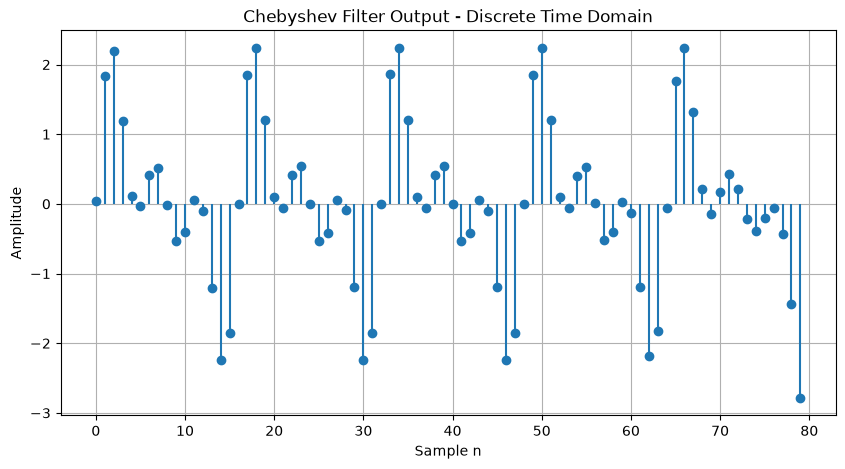

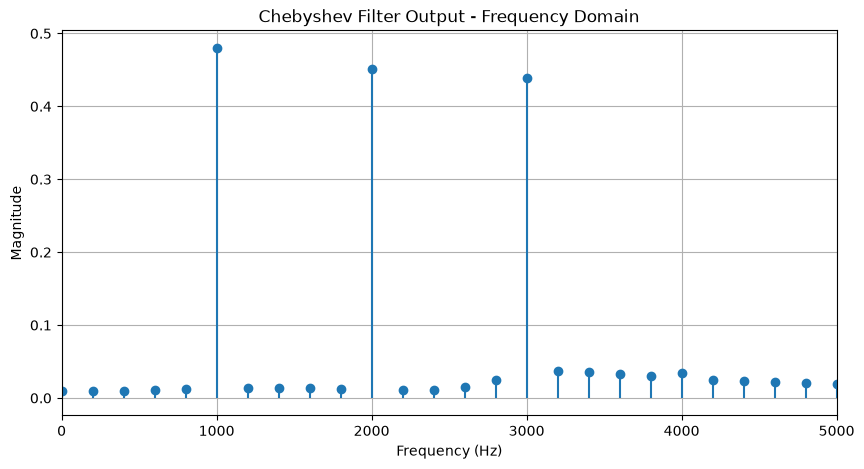

In [ ]:
#Discrete Signal
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, cheby1, sosfiltfilt

# 1. Sampling parameters
Fs = 16000          # Sampling frequency = 16 kHz
duration = 0.005    # Duration = 5 ms

n = np.arange(0, int(Fs * duration))
t = n / Fs

# 2. Generate four DISCRETE sine waves
f1 = 1000           # 1 kHz
f2 = 2000           # 2 kHz
f3 = 3000           # 3 kHz
f4 = 4000           # 4 kHz

x1 = np.sin(2 * np.pi * f1 * n / Fs)
x2 = np.sin(2 * np.pi * f2 * n / Fs)
x3 = np.sin(2 * np.pi * f3 * n / Fs)
x4 = np.sin(2 * np.pi * f4 * n / Fs)

# 3. Plot four discrete sine waves
plt.figure(figsize=(12, 9))

plt.subplot(4, 1, 1)
plt.stem(n[:80], x1[:80], basefmt=" ")
plt.title("Discrete Sine Wave - 1 kHz")
plt.xlabel("Sample n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.stem(n[:80], x2[:80], basefmt=" ")
plt.title("Discrete Sine Wave - 2 kHz")
plt.xlabel("Sample n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.stem(n[:80], x3[:80], basefmt=" ")
plt.title("Discrete Sine Wave - 3 kHz")
plt.xlabel("Sample n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.stem(n[:80], x4[:80], basefmt=" ")
plt.title("Discrete Sine Wave - 4 kHz")
plt.xlabel("Sample n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. Add all four discrete signals
x = x1 + x2 + x3 + x4

# 5. Plot combined signal in DISCRETE time domain
plt.figure(figsize=(10, 5))

plt.stem(n[:100], x[:100], basefmt=" ")

plt.title("Combined Discrete Signal - Time Domain")
plt.xlabel("Sample n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

# 6. Frequency Domain using FFT
N = len(x)

X = np.fft.fft(x)

freq = np.fft.fftfreq(N, 1/Fs)

magnitude = np.abs(X) / N

positive = freq >= 0

plt.figure(figsize=(10, 5))

plt.stem(
    freq[positive],
    magnitude[positive],
    basefmt=" "
)

plt.title("Combined Signal - Frequency Domain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.xlim(0, 5000)

plt.grid(True)
plt.show()

# 7. Butterworth Digital Low-Pass Filter
order = 4
cutoff_butter = 2000

sos_butter = butter(
    order,
    cutoff_butter,
    btype='lowpass',
    fs=Fs,
    output='sos'
)

butter_output = sosfiltfilt(
    sos_butter,
    x
)

# 8. Butterworth Output - DISCRETE Time Domain
plt.figure(figsize=(10, 5))

plt.stem(
    n[:100],
    butter_output[:100],
    basefmt=" "
)

plt.title("Butterworth Filter Output - Discrete Time Domain")
plt.xlabel("Sample n")
plt.ylabel("Amplitude")

plt.grid(True)
plt.show()

# 9. Butterworth Output - Frequency Domain
B = np.fft.fft(butter_output)

B_magnitude = np.abs(B) / N

plt.figure(figsize=(10, 5))

plt.stem(
    freq[positive],
    B_magnitude[positive],
    basefmt=" "
)

plt.title("Butterworth Filter Output - Frequency Domain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.xlim(0, 5000)

plt.grid(True)
plt.show()

# 10. Chebyshev Type-I Digital Low-Pass Filter
cutoff_cheby = 3000
ripple = 0.5

sos_cheby = cheby1(
    order,
    ripple,
    cutoff_cheby,
    btype='lowpass',
    fs=Fs,
    output='sos'
)

cheby_output = sosfiltfilt(
    sos_cheby,
    x
)
 
# 11. Chebyshev Output - DISCRETE Time Domain
plt.figure(figsize=(10, 5))

plt.stem(
    n[:100],
    cheby_output[:100],
    basefmt=" "
)

plt.title("Chebyshev Filter Output - Discrete Time Domain")
plt.xlabel("Sample n")
plt.ylabel("Amplitude")

plt.grid(True)
plt.show()

# 12. Chebyshev Output - Frequency Domain
C = np.fft.fft(cheby_output)

C_magnitude = np.abs(C) / N

plt.figure(figsize=(10, 5))

plt.stem(
    freq[positive],
    C_magnitude[positive],
    basefmt=" "
)

plt.title("Chebyshev Filter Output - Frequency Domain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.xlim(0, 5000)

plt.grid(True)
plt.show()